In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
column_names = [
    "checking_account_status",
    "duration_months",
    "credit_history",
    "purpose",
    "credit_amount",
    "savings_account",
    "employment_length",
    "installment_rate",
    "personal_status_sex",
    "other_debtors",
    "residence_since",
    "property",
    "age",
    "other_installment_plans",
    "housing",
    "existing_credits",
    "job",
    "people_liable",
    "telephone",
    "foreign_worker",
    "credit_risk"
]

In [3]:
df = pd.read_csv(
    "../data/raw/german.data",
    sep=" ",
    header=None,
    names=column_names
)

In [5]:
df.shape

(1000, 21)

In [6]:
df.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_length,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [7]:
df.tail()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_length,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,credit_risk
995,A14,12,A32,A42,1736,A61,A74,3,A92,A101,...,A121,31,A143,A152,1,A172,1,A191,A201,1
996,A11,30,A32,A41,3857,A61,A73,4,A91,A101,...,A122,40,A143,A152,1,A174,1,A192,A201,1
997,A14,12,A32,A43,804,A61,A75,4,A93,A101,...,A123,38,A143,A152,1,A173,1,A191,A201,1
998,A11,45,A32,A43,1845,A61,A73,4,A93,A101,...,A124,23,A143,A153,1,A173,1,A192,A201,2
999,A12,45,A34,A41,4576,A62,A71,3,A93,A101,...,A123,27,A143,A152,1,A173,1,A191,A201,1


In [8]:
df.sample(5)

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_length,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,credit_risk
787,A14,48,A34,A41,2751,A65,A75,4,A93,A101,...,A123,38,A143,A152,2,A173,2,A192,A201,1
945,A12,48,A30,A40,8358,A63,A72,1,A92,A101,...,A123,30,A143,A152,2,A173,1,A191,A201,1
301,A12,36,A30,A43,3804,A61,A73,4,A92,A101,...,A123,42,A143,A152,1,A173,1,A192,A201,2
677,A12,72,A32,A43,5595,A62,A73,2,A94,A101,...,A123,24,A143,A152,1,A173,1,A191,A201,2
732,A12,8,A32,A43,760,A61,A74,4,A92,A103,...,A121,44,A143,A152,1,A172,1,A191,A201,1


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   checking_account_status  1000 non-null   str  
 1   duration_months          1000 non-null   int64
 2   credit_history           1000 non-null   str  
 3   purpose                  1000 non-null   str  
 4   credit_amount            1000 non-null   int64
 5   savings_account          1000 non-null   str  
 6   employment_length        1000 non-null   str  
 7   installment_rate         1000 non-null   int64
 8   personal_status_sex      1000 non-null   str  
 9   other_debtors            1000 non-null   str  
 10  residence_since          1000 non-null   int64
 11  property                 1000 non-null   str  
 12  age                      1000 non-null   int64
 13  other_installment_plans  1000 non-null   str  
 14  housing                  1000 non-null   str  
 15  existing_credits

In [10]:
df["credit_risk"].value_counts()

credit_risk
1    700
2    300
Name: count, dtype: int64

In [11]:
df["credit_risk"].value_counts(normalize=True)

credit_risk
1    0.7
2    0.3
Name: proportion, dtype: float64

In [12]:
df.dtypes

checking_account_status      str
duration_months            int64
credit_history               str
purpose                      str
credit_amount              int64
savings_account              str
employment_length            str
installment_rate           int64
personal_status_sex          str
other_debtors                str
residence_since            int64
property                     str
age                        int64
other_installment_plans      str
housing                      str
existing_credits           int64
job                          str
people_liable              int64
telephone                    str
foreign_worker               str
credit_risk                int64
dtype: object

In [14]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_columns = df.select_dtypes(include=["object", "string", "str"]).columns.tolist()

In [15]:
print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['duration_months', 'credit_amount', 'installment_rate', 'residence_since', 'age', 'existing_credits', 'people_liable', 'credit_risk']

Categorical columns:
['checking_account_status', 'credit_history', 'purpose', 'savings_account', 'employment_length', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']


In [17]:
df.nunique().sort_values()  #Count unique values

credit_risk                  2
foreign_worker               2
telephone                    2
people_liable                2
other_installment_plans      3
housing                      3
other_debtors                3
checking_account_status      4
existing_credits             4
installment_rate             4
residence_since              4
job                          4
personal_status_sex          4
property                     4
credit_history               5
savings_account              5
employment_length            5
purpose                     10
duration_months             33
age                         53
credit_amount              921
dtype: int64

In [18]:
#Inspect categorical values

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts())


checking_account_status
checking_account_status
A14    394
A11    274
A12    269
A13     63
Name: count, dtype: int64

credit_history
credit_history
A32    530
A34    293
A33     88
A31     49
A30     40
Name: count, dtype: int64

purpose
purpose
A43     280
A40     234
A42     181
A41     103
A49      97
A46      50
A45      22
A44      12
A410     12
A48       9
Name: count, dtype: int64

savings_account
savings_account
A61    603
A65    183
A62    103
A63     63
A64     48
Name: count, dtype: int64

employment_length
employment_length
A73    339
A75    253
A74    174
A72    172
A71     62
Name: count, dtype: int64

personal_status_sex
personal_status_sex
A93    548
A92    310
A94     92
A91     50
Name: count, dtype: int64

other_debtors
other_debtors
A101    907
A103     52
A102     41
Name: count, dtype: int64

property
property
A123    332
A121    282
A122    232
A124    154
Name: count, dtype: int64

other_installment_plans
other_installment_plans
A143    814
A141    139
A142  

In [19]:
#Check for missing values

df.isnull().sum()

checking_account_status    0
duration_months            0
credit_history             0
purpose                    0
credit_amount              0
savings_account            0
employment_length          0
installment_rate           0
personal_status_sex        0
other_debtors              0
residence_since            0
property                   0
age                        0
other_installment_plans    0
housing                    0
existing_credits           0
job                        0
people_liable              0
telephone                  0
foreign_worker             0
credit_risk                0
dtype: int64

In [20]:
#Check for duplicate rows

df.duplicated().sum()

np.int64(0)

In [24]:
df.describe()

,duration_months,credit_amount,installment_rate,residence_since,age,existing_credits,people_liable,credit_risk
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


In [25]:
#Build a proper summary table

summary = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isnull().sum(),
    "missing_pct": df.isnull().mean() * 100,
    "unique": df.nunique()
})

summary

,dtype,missing,missing_pct,unique
checking_account_status,str,0,0.0,4
duration_months,int64,0,0.0,33
credit_history,str,0,0.0,5
purpose,str,0,0.0,10
credit_amount,int64,0,0.0,921
savings_account,str,0,0.0,5
employment_length,str,0,0.0,5
installment_rate,int64,0,0.0,4
personal_status_sex,str,0,0.0,4
other_debtors,str,0,0.0,3


## Machine Learning Objective

The goal of this project is to build a binary classification model
that estimates whether a credit applicant belongs to the bad-credit-risk
class using information available at the time of the credit application.

Target:

- 0 = Good credit risk
- 1 = Bad credit risk

The system should eventually return both:

1. Predicted class
2. Probability of bad credit risk

In [ ]:
#inspect every categorical column ourselves

categorical_columns = df.select_dtypes(include=["object", "string", "str"]
).columns.tolist()

categorical_columns

['checking_account_status',
 'credit_history',
 'purpose',
 'savings_account',
 'employment_length',
 'personal_status_sex',
 'other_debtors',
 'property',
 'other_installment_plans',
 'housing',
 'job',
 'telephone',
 'foreign_worker']

In [29]:
for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts())


--- checking_account_status ---
checking_account_status
A14    394
A11    274
A12    269
A13     63
Name: count, dtype: int64

--- credit_history ---
credit_history
A32    530
A34    293
A33     88
A31     49
A30     40
Name: count, dtype: int64

--- purpose ---
purpose
A43     280
A40     234
A42     181
A41     103
A49      97
A46      50
A45      22
A44      12
A410     12
A48       9
Name: count, dtype: int64

--- savings_account ---
savings_account
A61    603
A65    183
A62    103
A63     63
A64     48
Name: count, dtype: int64

--- employment_length ---
employment_length
A73    339
A75    253
A74    174
A72    172
A71     62
Name: count, dtype: int64

--- personal_status_sex ---
personal_status_sex
A93    548
A92    310
A94     92
A91     50
Name: count, dtype: int64

--- other_debtors ---
other_debtors
A101    907
A103     52
A102     41
Name: count, dtype: int64

--- property ---
property
A123    332
A121    282
A122    232
A124    154
Name: count, dtype: int64

--- other_inst

## Feature Investigation

In [30]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

numerical_columns

['duration_months',
 'credit_amount',
 'installment_rate',
 'residence_since',
 'age',
 'existing_credits',
 'people_liable',
 'credit_risk']

In [32]:
#Remove the target

numerical_features = [
    col for col in numerical_columns
    if col != "credit_risk"
]

numerical_features

['duration_months',
 'credit_amount',
 'installment_rate',
 'residence_since',
 'age',
 'existing_credits',
 'people_liable']

In [37]:
df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
duration_months,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
credit_amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
installment_rate,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
residence_since,1000.0,2.845,1.103718,1.0,2.0,3.0,4.00,4.0
age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
existing_credits,1000.0,1.407,0.577654,1.0,1.0,1.0,2.00,4.0
people_liable,1000.0,1.155,0.362086,1.0,1.0,1.0,1.00,2.0


In [40]:
df["credit_risk"].value_counts(normalize=True) * 100

credit_risk
1    70.0
2    30.0
Name: proportion, dtype: float64

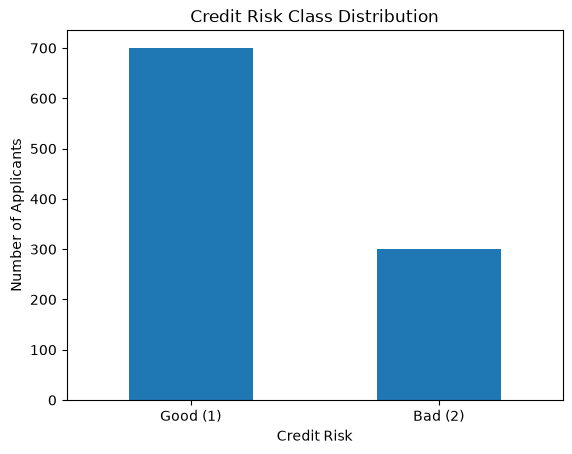

In [41]:
#Visualize the target variable

target_counts = df["credit_risk"].value_counts().sort_index()

target_counts.plot(kind="bar")

plt.title("Credit Risk Class Distribution")
plt.xlabel("Credit Risk")
plt.ylabel("Number of Applicants")
plt.xticks(
    ticks=[0, 1],
    labels=["Good (1)", "Bad (2)"],
    rotation=0
)

plt.show()

## Feature Types

| Feature | Type | Notes |
|---|---|---|
| checking_account_status | Ordinal categorical | Account balance/status |
| duration_months | Numerical | Credit duration |
| credit_history | Categorical | Previous credit history |
| purpose | Nominal categorical | Purpose of credit |
| credit_amount | Numerical | Amount of credit |
| savings_account | Ordinal categorical | Savings level |
| employment_length | Ordinal categorical | Employment duration |
| age | Numerical | Potentially sensitive |
| housing | Nominal categorical | Rent / own / free |
| credit_risk | Target | 1 = good, 2 = bad |